In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
import time

**1) Выбираю WineQT DataSet**

In [15]:
df = pd.read_csv('/content/WineQT.csv')

**2) Первичный анализ данных**

In [21]:
print("First dataset strings::")
display(df.head())
print("Columns info::")
df.info()
print("\nNumeric columns statistics::")
display(df.describe())
print("\nMissing values per column::")
print(df.isnull().sum())
print("\nQuality allocation::")
df['quality'].value_counts()

First dataset strings::


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Columns info::
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

Numeric columns statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000



Missing values per column::
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Quality allocation::


,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


Размер: 1143 строк и 13 столбцов (11 признаков + quality + Id).

Типы признаков: числовые (float64 или int64)

Пропуски: пропусков нет

Распределение классов: большинство вин имеют оценку 5 или 6 в оценке класса quality, вина с оценкой 3 или 8 встречаются крайне редко.

Структура и статистика: признаки имеют разный масштаб (citric acid max=1.0000, total sulfur dioxide max=289.0000)

**3) Подготовка данных**

In [22]:
# Features and target
y = df['quality']
X = df.drop(['Id', 'quality'], axis=1)
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# train / test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

*почему масштабирование важно для KNN*

масштабирование необходимо для того, чтобы все признаки имели одинаковый вес при вычислении расстояния между точками (а значит и при определении принадлежности той или иной категории quality)

*почему нельзя подбирать параметры на тестовой выборке*

"подгонка" параметров не поможет полностью оценить эффективность построенной модели

**4) Обучение kNN**

In [30]:
k_neighbors = [1, 5, 10, 15, 25, 50]
metrics = ['euclidean', 'manhattan', 'minkowski']
weights = ['uniform', 'distance']
results = []
for k in k_neighbors:
    for metric in metrics:
        for weight in weights:
            knn = KNeighborsClassifier(n_neighbors=k, weights=weight, metric=metric)
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)
            train_accuracy = knn.score(X_train, y_train)
            test_accuracy = knn.score(X_test, y_test)
            results.append({
                'k': k,
                'metric': metric,
                'weight': weight,
                'train_accuracy': train_accuracy,
                'test_accuracy': test_accuracy,
            })
results_df = pd.DataFrame(results)
display(results_df)

,k,metric,weight,train_accuracy,test_accuracy
0,1,euclidean,uniform,1.000000,0.650655
1,1,euclidean,distance,1.000000,0.650655
2,1,manhattan,uniform,1.000000,0.646288
3,1,manhattan,distance,1.000000,0.646288
4,1,minkowski,uniform,1.000000,0.650655
5,1,minkowski,distance,1.000000,0.650655
6,5,euclidean,uniform,0.678337,0.567686
7,5,euclidean,distance,1.000000,0.633188
8,5,manhattan,uniform,0.682713,0.585153
9,5,manhattan,distance,1.000000,0.650655


При k: 25,
metric: manhattan,
weights: distance, получено лучшее значение
accuracy: ~0.707

**5) Подбор гиперпараметров**

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'knn__n_neighbors': [5, 10, 15, 25, 50],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

# Set up cross-validation search (cv=5)
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")

Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 50, 'knn__weights': 'distance', 'scaler': StandardScaler()}
Best cross-validation accuracy: 0.650


Множественные замеры accuracy при кросс-валидации позволили получить более честный результат в 0.650

Финальный отчет по метрикам:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.79      0.76        97
           6       0.63      0.76      0.69        92
           7       0.92      0.38      0.54        29
           8       0.00      0.00      0.00         3

    accuracy                           0.69       229
   macro avg       0.38      0.32      0.33       229
weighted avg       0.68      0.69      0.67       229



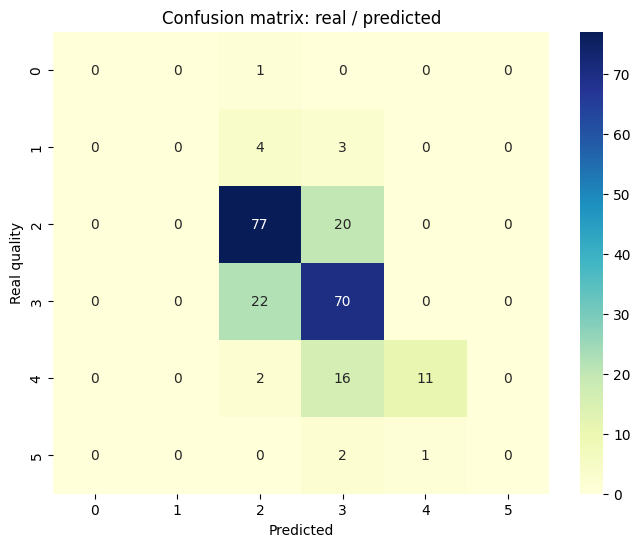

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = grid_search.predict(X_test)

print("Финальный отчет по метрикам:")
print(classification_report(y_test, y_pred, zero_division=0))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion matrix: real / predicted')
plt.xlabel('Predicted')
plt.ylabel('Real quality')
plt.show()

- Из-за преобладания средних категорий (5 или 6) наилучший результат точности достигается при большем количестве соседей (k=50 в нашем случае)
- в это же время recall и confusion matrix показывают, что редкие категории 3, 4, 8 не распознаются и поглощаются соседями при k=50 (recall у 3, 4, 8=0.00)

Данный факт следует из несбалансированности данных, обнаруженной еще при первичном анализе